# LAMOST CN 增强星筛选：诊断与样本扩充实验合集

## 这份 notebook 要回答一个问题

项目从一开始就有一个很自然的想法：

> **"我们只有 91 颗已知 CN 星，太少了，模型训不好。
> 能不能多标一些样本，再训一次，把筛选质量提上去？"**

在投入观测资源之前，我们用四组实验来判断这条路**能不能走通、能走多远、以及代价是什么**。

## 叙事线：四步

| 步骤 | 问题 | 用到的数据 | 产出 |
|---|---|---|---|
| **Part 1** | 模型到底哪里不行？ | 91 颗 + 41,243 条 OOF 分数 | 分数谱、特征空间邻域结构 |
| **Part 2** | 候选池可靠吗？ | 654 颗候选 + 91 颗标尺 | 富集度阶梯、候选分层 |
| **Part 3** | 加样本有用吗？ | **99 个独立高分辨率标签** | 5 种加入方式的受控对照 |
| **Part 4** | 那"准确度"到底是多少？ | 同一批独立标签 | 自证口径 vs 独立口径 |

四步是递进的：**先搞清楚病灶在哪，再判断药有没有用，最后校准体检报告本身可不可信。**

## 关键背景（读之前需要知道的几件事）

1. **91 颗已知 CN 星是 ground truth**：文献 + 高分辨率光谱双重确认，标签噪声视为零。是整个项目的基本依据。
2. **任务本质是 PU 学习**：只知道"哪些是正类"，不知道"哪些是负类"。未标注集 U 里既有真正的 CN 星，也有普通星。
3. **分数不叫概率**：PU 平衡采样下 `binary:logistic` 的输出只在 [0,1] 区间内，不恢复巡天先验。全文统一称 **score**。
4. **两套模型**：
   - `xgb_threshold`：单次 train/test 划分、500 bags、等概率负采样。README 里的"标杆"。
   - `crossfit`：5 折 × 3 重复交叉拟合、100 bags、U:P=10:1。每个对象都有样本外分数。
5. **99 个独立标签**（`cands_label.csv`）：46 颗高分辨率确认为 CN 增丰，53 颗查验为非增丰。
   它们在上述模型训练时**完全未知**——这是项目第一次拥有真正的外部尺子。

## 一句话预告结论

> **加样本方向没错，但收益的上限由"特征里有多少 CN 信息"决定，而不是由样本数量决定。**
> 而且这条路真正的第一个收获，不是更好的模型，而是**第一次能测出模型的真实准确度**。

---


## 0. 环境与共享工具

本 notebook 的设计原则：**只读结果，不重算**。
所有重计算都已在 `diagnosis/` 的脚本里完成，结果落盘为 JSON / CSV / PNG。
这样执行只需几秒，你可以反复运行、随便改。

In [1]:
# 共享环境：路径定位 + 读取工具
#
# 本 notebook 不加载 700 维光谱缓存，只读取 diagnosis/results/ 下已经由
# 四个实验脚本产出的结果文件。因此执行只需几秒，可以反复运行。

import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
import warnings
warnings.filterwarnings("ignore")

# 中文与负号显示
matplotlib.rcParams.update({
    "font.size": 10,
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 110,
})

# 向上查找项目根目录（同时存在 diagnosis/ 与 build_dr13_all_cache.py）
_PROJECT_ROOT = Path(os.getcwd())
for _ in range(6):
    if (_PROJECT_ROOT / "diagnosis").exists() and (_PROJECT_ROOT / "build_dr13_all_cache.py").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent

DIAG = _PROJECT_ROOT / "diagnosis"
RES  = DIAG / "results"


def load_json(name):
    """读取 results/ 下的 JSON 结果文件。"""
    return json.loads((RES / name).read_text(encoding="utf-8"))


def load_csv(name, **kw):
    """读取 results/ 下的 CSV 结果文件。"""
    return pd.read_csv(RES / name, **kw)


def show_fig(name, width=880):
    """显示已保存的结果图。"""
    display(Image(filename=str(RES / name), width=width))


assert RES.exists(), f"未找到结果目录: {RES}"
print(f"项目根目录 : {_PROJECT_ROOT}")
print(f"结果目录   : {RES}")
print(f"结果文件   : {len(list(RES.glob('*')))} 个")


项目根目录 : D:\资料\2026大创\Lamost
结果目录   : D:\资料\2026大创\Lamost\diagnosis\results
结果文件   : 23 个


In [2]:
# 冻结的 crossfit 分数（全量 41,243 条样本外分数）
#
# 这是后续几乎所有诊断的基础：每个对象都有一个"没被自己训练过的模型"给出的分数。
# 文件里同时存了 label，所以可以直接把已知正例和未标注样本分开。

FROZEN_NPZ = (_PROJECT_ROOT / "crossfit" / "results" / "recall90" / "formal"
              / "crossfit_arrays_recall90.npz")

blob        = np.load(FROZEN_NPZ, allow_pickle=True)   # uid 是 object 数组，必须 allow_pickle
score_all   = np.asarray(blob["score_mean"], dtype=float)
label_frozen = np.asarray(blob["label"])
uid_all     = blob["uid"].astype(str)

n_pos = int((label_frozen == 1).sum())
print(f"样本总数     : {score_all.size:,}")
print(f"已知正例     : {n_pos}")
print(f"未标注样本   : {int((label_frozen == -1).sum()):,}")
print(f"分数范围     : {score_all.min():.4f} ~ {score_all.max():.4f}")
print()
print("这是一个 PU（Positive-Unlabeled）任务：只有正类标签，没有可靠负类。")


样本总数     : 41,243
已知正例     : 91
未标注样本   : 41,152
分数范围     : 0.0047 ~ 0.9929

这是一个 PU（Positive-Unlabeled）任务：只有正类标签，没有可靠负类。


---
# Part 1 — 模型到底哪里不行？

## 1.1 一个被忽略的前提

"91 颗太少所以模型不好"——这句话人人都会说，但它**不是一个诊断，而是一个假设**。
要判断它成不成立，得先回答两个更具体的问题：

1. **模型在这 91 颗上，究竟表现成什么样？** 是全都学不会，还是只有少数几颗学不会？
2. **如果只有少数几颗难，它们在特征空间里长什么样？** 是"信息不够"，还是"样本太少"？

这两个问题的答案完全不同：
- 如果是**信息不够**（这颗星的低分辨率光谱和普通星没有区别）→ 加多少样本都没用；
- 如果是**样本太少**（这颗星和普通星有区别，只是模型没见过同类）→ 加样本有用。

Part 1 就是用数据把这两者分开。

## 1.2 方法：D1 分数谱 + D2 局部密度

**D1（分数谱）**：把 91 颗已知正例的样本外分数，放进 41,152 个未标注样本的分数分布里看。
如果某颗正例的分数落在 U 的分布内部，说明模型"完全不认为它像正类"。

**D2（局部密度）**：在模型实际使用的标准化 700 维空间里，
统计每颗对象的 k 近邻中有几颗已知正例。
- 随机期望 = `k × 91 / 41243`（k=50 时是 0.110）
- 如果正例的近邻里正例显著多于随机 → 正类在特征空间里**成簇**，是可学的
- 如果和随机差不多 → 正类**散落在 U 里**，学不出来

> **为什么必须有"随机对照"**：在 700 维空间里任何两个对象都有近邻，
> 距离比值天然接近 1，绝对值本身没有信息。
> 只有和"随机抽同样数量的 U"比较，才能判断观察值是否异常。


In [3]:
# D1：91 颗已知正例的分数落在 U 分布的什么位置

pos = label_frozen == 1
u_scores   = np.sort(score_all[~pos])
pos_scores = score_all[pos]

# 每颗正例的分数在 U 分布中的百分位
pct = np.searchsorted(u_scores, pos_scores, side="right") / u_scores.size * 100

# 冻结结果里 90% 召回标定出的阈值
THR = load_json("density_metrics.json")["threshold"]

print(f"U 分数中位数        : {np.median(u_scores):.4f}")
print(f"90% 召回阈值        : {THR:.6f}")
print(f"正例 ≥ 阈值         : {(pos_scores >= THR).sum()} / {pos_scores.size}")
print(f"正例 < 阈值（漏检） : {(pos_scores < THR).sum()} / {pos_scores.size}")
print()

bands = [(0, 25), (25, 50), (50, 75), (75, 90), (90, 95), (95, 100)]
rows = []
for lo, hi in bands:
    n = int(((pct > lo) & (pct <= hi)).sum())
    rows.append({"分数在 U 中的百分位区间": f"{lo}–{hi}%", "正例数": n,
                 "可视化": "█" * n})
print(pd.DataFrame(rows).to_string(index=False))
print()
print(f"落在 U 最高的 5% 区间内的正例：{int((pct > 95).sum())}/91")
print(f"分数低于 U 中位数的正例：      {int((pct <= 50).sum())}/91")


U 分数中位数        : 0.0101
90% 召回阈值        : 0.137546
正例 ≥ 阈值         : 82 / 91
正例 < 阈值（漏检） : 9 / 91

分数在 U 中的百分位区间  正例数                                                                                   可视化
        0–25%    2                                                                                    ██
       25–50%    0                                                                                      
       50–75%    2                                                                                    ██
       75–90%    0                                                                                      
       90–95%    2                                                                                    ██
      95–100%   85 █████████████████████████████████████████████████████████████████████████████████████

落在 U 最高的 5% 区间内的正例：85/91
分数低于 U 中位数的正例：      2/91


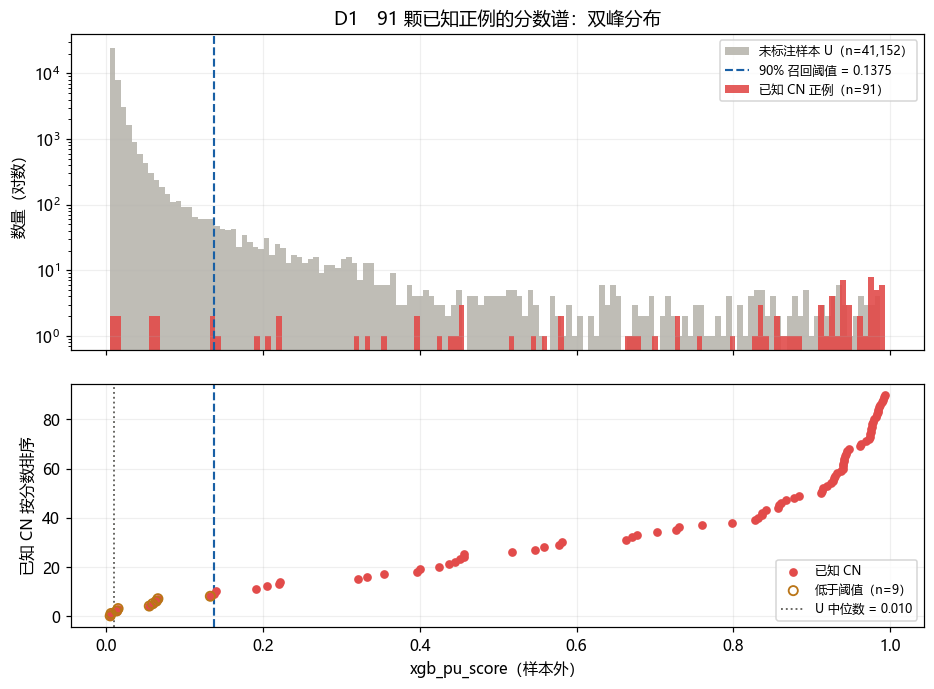

In [4]:
# 直观画一遍分数谱（不需要加载光谱缓存，直接用冻结分数）

fig, axes = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[1.3, 1],
                         sharex=True, gridspec_kw={"hspace": 0.12})

ax = axes[0]
ax.hist(u_scores, bins=140, color="#B4B2A9", alpha=0.85,
        label=f"未标注样本 U（n={u_scores.size:,}）")
ax.set_yscale("log")
ax.axvline(THR, color="#185FA5", ls="--", lw=1.4, label=f"90% 召回阈值 = {THR:.4f}")
ax.hist(pos_scores, bins=140, color="#E24B4A", alpha=0.9,
        label=f"已知 CN 正例（n={pos_scores.size}）")
ax.set_ylabel("数量（对数）")
ax.set_title("D1　91 颗已知正例的分数谱：双峰分布", fontsize=12)
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.2)

ax = axes[1]
order = np.argsort(pos_scores)
s = pos_scores[order]
ax.scatter(s, np.arange(s.size), s=22, c="#E24B4A", zorder=3, label="已知 CN")
below = s < THR
ax.scatter(s[below], np.arange(s.size)[below], s=36, facecolors="none",
           edgecolors="#BA7517", linewidths=1.2, zorder=4,
           label=f"低于阈值（n={int(below.sum())}）")
ax.axvline(THR, color="#185FA5", ls="--", lw=1.4)
ax.axvline(np.median(u_scores), color="#5F5E5A", ls=":", lw=1.2,
           label=f"U 中位数 = {np.median(u_scores):.3f}")
ax.set_xlabel("xgb_pu_score（样本外）")
ax.set_ylabel("已知 CN 按分数排序")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


### 1.3 怎么读这张图

**这是一个明显的双峰分布，不是"模型很差"的样子。**

- **85/91（93.4%）落在 U 的最高 5%** —— 绝大多数正例被模型干净地识别出来了；
- **只有 9 颗低于阈值**，其中 7 颗分数还在 U 的中位数之上（只是没到阈值），
  **真正落进 U 分布内部的只有 2 颗**；
- 换句话说：模型对 91 颗正例的判别力**极强**，问题高度集中在少数几颗上。

**这直接修正了"91 颗太少所以模型不好"这个说法**——
不是 91 颗都学不会，而是有 2–9 颗特殊对象学不会。规模比直觉小得多。

> 顺带说明一个容易踩的坑：crossfit 的阈值是**按 91 颗自己的分数分位数反标定**的
> （取第 82 高的分数），所以"82/91"不是模型的自然能力，而是标定结果。
> 只要把阈值降得足够低，任何召回率都能达到，代价是候选数暴涨。
> 因此**判读要看分数的分布形状，而不是"命中了几颗"**。


In [5]:
# D2：特征空间里，正类到底成不成簇？
# 统计量 = 每颗对象的 50 近邻中有几颗已知正例；随机期望 = 50 × 91 / 41243

m = load_json("density_metrics.json")
d2 = m["d2"]
nc = m["null_controls"]

print("【全局聚类度】正例到最近正例的距离 ÷ 正例到最近 U 的距离")
print(f"  实测 ratio        : {d2['ratio_pp_pu_mean']:.4f}")
print(f"  随机对照（200 次）: {nc['null_ratio_mean']:.4f} ± {nc['null_ratio_std']:.4f}")
print(f"  显著性            : z = {m['significance']['ratio_z_vs_null']:+.2f}, "
      f"p = {m['significance']['ratio_p_value_lower_tail']:.3f}")
print(f"  判据（预先固定）  : <0.7 成簇 / 0.7–1.0 部分成簇 / >1.0 松散")
print(f"  → 结论            : {d2['ratio_pp_pu_verdict']}")
print()
print("【邻域富集】每颗正例的 k 近邻中有多少颗代理新样本")
rows = []
for k in ("k50", "k200"):
    e = d2["knn_enrichment"][k]
    rows.append({"k": k[1:],
                 "随机期望": e["expected_random_count"],
                 "实测均值": e["mean_count"],
                 "富集倍数": e["mean_count"] / e["expected_random_count"],
                 "至少命中 1 颗的正例": f"{e['n_positives_with_any_new_neighbour']}/91"})
print(pd.DataFrame(rows).round(3).to_string(index=False))


【全局聚类度】正例到最近正例的距离 ÷ 正例到最近 U 的距离
  实测 ratio        : 1.0839
  随机对照（200 次）: 1.2528 ± 0.0219
  显著性            : z = -7.71, p = 0.000
  判据（预先固定）  : <0.7 成簇 / 0.7–1.0 部分成簇 / >1.0 松散
  → 结论            : weak_or_scattered

【邻域富集】每颗正例的 k 近邻中有多少颗代理新样本
  k  随机期望  实测均值   富集倍数 至少命中 1 颗的正例
 50 0.164 2.934 17.927       64/91
200 0.655 6.824 10.424       76/91


### 1.4 邻域富集：新样本落在哪里？

上面看到正类在特征空间里成簇（虽然松散）。接下来的问题是：
**代理新样本（二级筛选两法一致的 135 颗）落在哪里？**

统计量：每颗正例的 k 近邻中有多少颗代理新样本，与随机期望比较。
关键在于**按模型表现分层拆开看**。

                       分层  颗数  50 近邻中新样本均值  中位数
         easy（模型已抓住，82 颗）  82        3.256  2.0
         medium（低于阈值，7 颗）   7        0.000  0.0
hard（低于阈值且分数 < U 中位数，2 颗）   2        0.000  0.0

模型漏掉的正例共 9 颗，其中被新样本『针对性覆盖』的：0 颗



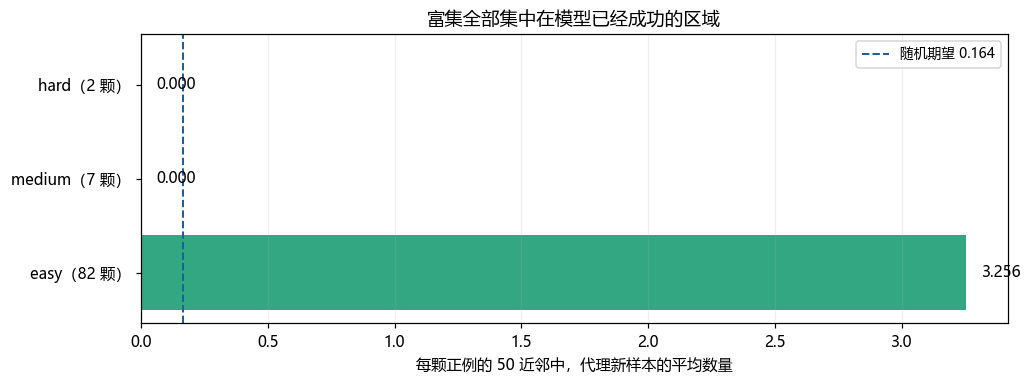

In [6]:
# D2 最关键的拆分：富集到底落在谁身上？
#
# 把 91 颗正例按"模型是否已经抓住"分层，看每层的新样本邻域富集。
# 如果富集全部落在 easy 上、missed 上一颗都没有，说明：
# 按当前提名方式加样本，恰好会绕开模型的所有失败区域。

tier = load_json("density_metrics.json")["tier_enrichment_k50"]
rows = []
label_map = {"easy": "easy（模型已抓住，82 颗）",
             "medium": "medium（低于阈值，7 颗）",
             "hard": "hard（低于阈值且分数 < U 中位数，2 颗）"}
for key in ("easy", "medium", "hard"):
    t = tier[key]
    rows.append({"分层": label_map[key], "颗数": int(t["count"]),
                 "50 近邻中新样本均值": t["mean"], "中位数": t["median"]})
print(pd.DataFrame(rows).round(3).to_string(index=False))
print()

missed = load_json("density_metrics.json")["missed_positives"]
print(f"模型漏掉的正例共 {missed['n_missed']} 颗，"
      f"其中被新样本『针对性覆盖』的：{missed['n_missed_targeted']} 颗")
print()

fig, ax = plt.subplots(figsize=(9.5, 3.6))
names = ["easy（82 颗）", "medium（7 颗）", "hard（2 颗）"]
vals  = [tier["easy"]["mean"], tier["medium"]["mean"], tier["hard"]["mean"]]
bars = ax.barh(names, vals, color=["#1D9E75", "#888780", "#BA7517"], alpha=0.9)
ax.axvline(load_json("density_metrics.json")["d2"]["knn_enrichment"]["k50"]["expected_random_count"],
           color="#185FA5", ls="--", lw=1.3, label="随机期望 0.164")
for b, v in zip(bars, vals):
    ax.text(v + 0.06, b.get_y() + b.get_height() / 2, f"{v:.3f}",
            va="center", fontsize=10)
ax.set_xlabel("每颗正例的 50 近邻中，代理新样本的平均数量")
ax.set_title("富集全部集中在模型已经成功的区域", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.2, axis="x")
plt.tight_layout()
plt.show()


### 1.4 Part 1 小结

**问题**：模型哪里不行？

| 发现 | 数字 | 含义 |
|---|---|---|
| 正例分数的分布是双峰的 | 85/91 落在 U 最高 5% | 模型判别力很强，问题高度集中 |
| 真正落进 U 内部的只有 | **2 颗** | "91 颗都学不会"不成立 |
| 正类在特征空间里成簇吗 | ratio 1.084 vs 随机 1.253（p<0.005） | **成簇，但很松散**——每颗正例的最近邻仍是普通星 |
| 代理新样本对正例富集 | 17.9 倍（k=50） | 候选确实携带真实信息 |
| **富集落在哪里** | easy 3.256 / medium **0.000** / hard **0.000** | **完全绕开模型失败区** |

**结论**：
1. **特征空间里存在可学的正类结构**（统计显著），所以"提高正例在关键区域的局部密度"这个思路在原理上成立；
2. **但当前这批代理样本对模型的漏检零帮助**——它们几乎全部落在模型已经认对的 82 颗附近；
3. 这不是"加样本没用"，而是**"这样挑样本没用"**：候选池来自"模型高分 ∩ 物理筛选"，提名的第一步就是模型打分，自然只能覆盖模型认可的区域。

**这一步的意义**：把"要不要加样本"这个笼统问题，变成了"**加在哪里的样本有用**"这个可操作问题。


---
# Part 2 — 候选池可靠吗？

## 2.1 一个可以回答的问题，和一个无法回答的问题

**无法回答**："654 颗候选里有多少是真的？" —— 没有独立标签，无从判断。

**可以回答**："这 654 颗候选，**相对于 91 颗 ground truth**，处在什么位置？"

后者的关键，是设计一个**在正例组和候选组之间可直接比较**的统计量。

## 2.2 方法：用 ground truth 做标尺

对每一个对象，统计它的 **k 近邻中有几颗已知正例**：

- **91 颗正例**：近邻表里数"其他正例"（自身掩掉）
- **候选**：近邻表里数"已知正例"（候选不是正例，不存在自污染）
- 两组按**完全相同的口径**计算，因此可比
- 随机期望 = `k × 91 / 41243`，k=50 时为 **0.110**

这个比值（实测 ÷ 随机期望）就是**富集倍数**。

**直觉**：一颗对象如果真的是 CN 星，它在特征空间里应该靠近其他 CN 星。
富集倍数直接量化了这件事，而且不需要知道候选的真假标签。

## 2.3 要比较的几组

| 组 | 含义 | 数量 |
|---|---|---:|
| `both` | 指数法 **和** 面积法都支持 | 135 |
| `index-only` | 只有指数法支持 | 24 |
| `area-only` | 只有面积法支持 | 12 |
| `neither` | 模型高分，但两个光谱方法都否 | 483 |
| `all` | 全部冻结候选 | 654 |
| 已知正例（标尺） | — | 91 |


In [7]:
# 富集度阶梯：各组的"已知正例邻域富集"倍数
#
# 这是本 Part 最重要的一张表。注意第一行——它颠覆了一个直觉。

m = load_json("candidate_metrics.json")
e50 = m["enrichment_summary"]["k50"]
order = ["neither", "area_only", "index_only", "both", "tier1", "all"]
name_cn = {
    "neither":      "模型高分但两法都否",
    "area_only":    "仅面积法支持",
    "index_only":   "仅指数法支持",
    "both":         "两法一致",
    "tier1":        "两法任一支持（合计）",
    "all":          "全部 654 候选",
}
rows = []
for k in order:
    e = e50[k]
    rows.append({
        "组": name_cn[k], "n": e["n"],
        "k=50 富集倍数": e["enrichment_factor"],
        "零富集占比": f"{e['share_zero'] * 100:.1f}%",
    })
rows.append({"组": "★ 已知正例（标尺）", "n": 91,
             "k=50 富集倍数": e50["known_positives_mean"] / e50["random_expectation"],
             "零富集占比": "—"})
rows.append({"组": "　 随机抽样（基准）", "n": "—",
             "k=50 富集倍数": 1.0, "零富集占比": "—"})

# area_only 按富集升序排到前面更直观，这里保持语义顺序
df = pd.DataFrame(rows)
print(df.round(2).to_string(index=False))
print()
print(f"两法一致的增益 = {e50['both']['enrichment_factor'] / e50['neither']['enrichment_factor']:.2f} 倍")
print("（如果两者是『相互独立的双重证据』，这个数字应该远大于 2）")


         组   n  k=50 富集倍数 零富集占比
 模型高分但两法都否 483      12.95 54.9%
    仅面积法支持  12       4.53 83.3%
    仅指数法支持  24      21.15 41.7%
      两法一致 135      25.98 37.8%
两法任一支持（合计） 171      23.80 41.5%
 全部 654 候选 654      15.79 51.4%
★ 已知正例（标尺）  91      64.94     —
　 随机抽样（基准）   —       1.00     —

两法一致的增益 = 2.01 倍
（如果两者是『相互独立的双重证据』，这个数字应该远大于 2）


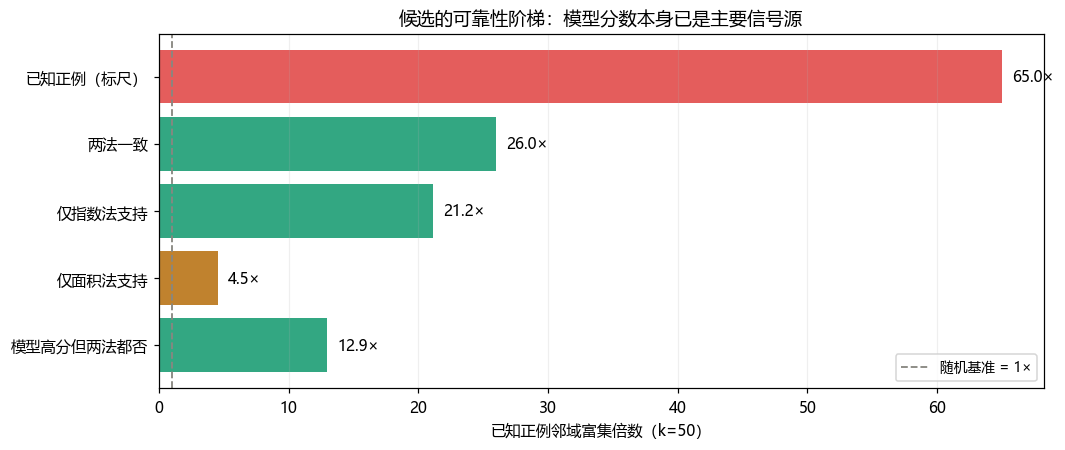

读法：
  · 『两法都否』仍有 12.9× → 说明 XGBoost 分数本身就是一个很强的选择器
  · 加光谱筛选后升到 26.0× → 二级筛选的作用是『翻倍』，不是『重新发现』
  · 但已知正例自身是 65× → 候选整体仍未达到 ground truth 的水平


In [8]:
# 把阶梯画出来

fig, ax = plt.subplots(figsize=(9.8, 4.2))
plot_order = ["neither", "area_only", "index_only", "both"]
vals = [e50[k]["enrichment_factor"] for k in plot_order] + [65.0]
labels = ["模型高分但两法都否", "仅面积法支持", "仅指数法支持", "两法一致",
          "已知正例（标尺）"]
colors = ["#1D9E75", "#BA7517", "#1D9E75", "#1D9E75", "#E24B4A"]
bars = ax.barh(labels, vals, color=colors, alpha=0.9)
ax.axvline(1.0, color="#888780", ls="--", lw=1.2, label="随机基准 = 1×")
for b, v in zip(bars, vals):
    ax.text(v + 0.8, b.get_y() + b.get_height() / 2, f"{v:.1f}×",
            va="center", fontsize=10)
ax.set_xlabel("已知正例邻域富集倍数（k=50）")
ax.set_title("候选的可靠性阶梯：模型分数本身已是主要信号源", fontsize=12)
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.2, axis="x")
plt.tight_layout()
plt.show()

print("读法：")
print("  · 『两法都否』仍有 12.9× → 说明 XGBoost 分数本身就是一个很强的选择器")
print("  · 加光谱筛选后升到 26.0× → 二级筛选的作用是『翻倍』，不是『重新发现』")
print("  · 但已知正例自身是 65× → 候选整体仍未达到 ground truth 的水平")


In [9]:
# 两个光谱方法不等价：指数法 >> 面积法
#
# feature/ 的方案把两者当作"两条互补的独立测量路径"。
# 用 ground truth 标尺一量，这个前提不成立。

rows = []
for k in ("index_only", "area_only"):
    e = e50[k]
    rows.append({
        "组": name_cn[k], "n": e["n"],
        "k=50 富集倍数": e["enrichment_factor"],
        "零富集占比": f"{e['share_zero'] * 100:.1f}%",
    })
print(pd.DataFrame(rows).round(2).to_string(index=False))
print()
print("指数法（CN3839 / CN4142 标准谱指数）携带主要信息；")
print("面积法单独使用时，83% 的成员近邻里一颗已知正例都没有。")
print()
print("这与另一个已知事实一致：两法 z-score 的 Pearson 相关系数高达 0.97（高度冗余），")
print("所以『两法一致』并不构成两倍可信度。")


     组  n  k=50 富集倍数 零富集占比
仅指数法支持 24      21.15 41.7%
仅面积法支持 12       4.53 83.3%

指数法（CN3839 / CN4142 标准谱指数）携带主要信息；
面积法单独使用时，83% 的成员近邻里一颗已知正例都没有。

这与另一个已知事实一致：两法 z-score 的 Pearson 相关系数高达 0.97（高度冗余），
所以『两法一致』并不构成两倍可信度。


### 2.4 候选集是异质混合体

如果候选是"一个同质的真 CN 星集合"，那它们应该普遍表现出高富集。
实际不是。

In [10]:
# 候选集是异质混合体，不能整体当作正样本

m = load_json("candidate_metrics.json")
cm = m["candidates_reaching_known_median"]

print(f"两法一致的 135 颗里，k=50 近邻中『没有任何已知正例』的比例："
      f"{e50['both']['share_zero'] * 100:.1f}%")
print(f"tier1 共 {m['group_sizes']['tier1']} 颗候选，其中达到已知正例"
      f"中位富集水平（≥{cm['threshold_count']:.0f}）的："
      f"{cm['n']} 颗（{cm['share'] * 100:.1f}%）")
print()

tbl = load_csv("candidate_reliability.csv")
top = tbl.nlargest(10, "knn50_known_positives")[
    ["uid", "group", "knn50_known_positives", "xgb_pu_score", "teff", "logg", "feh"]]
top.columns = ["uid", "分组", "50 近邻中的已知正例数", "score", "Teff", "log g", "[Fe/H]"]
print("富集度最高的 10 颗候选（可直接作为高分辨率观测的第一批对象）：")
print(top.round(2).to_string(index=False))


两法一致的 135 颗里，k=50 近邻中『没有任何已知正例』的比例：37.8%


tier1 共 171 颗候选，其中达到已知正例中位富集水平（≥6）的：26 颗（15.2%）

富集度最高的 10 颗候选（可直接作为高分辨率观测的第一批对象）：
            uid   分组  50 近邻中的已知正例数  score    Teff  log g  [Fe/H]
G14502126087737 both            23   0.98 4956.85   2.47   -0.98
L15968094080310 both            18   0.98 4773.54   1.88   -1.06
G15626569425898 both            18   0.94 5091.62   2.19   -1.07
G14866615886127 both            17   0.99 4904.80   1.94   -1.96
G15461721789897 both            17   0.83 4959.17   2.39   -1.22
G16051863705733 both            15   0.93 5079.71   2.82   -1.18
G16665632766330 both            14   0.88 4851.71   2.07   -1.42
G13889826793626 both            11   0.92 4839.70   2.03   -1.21
G15347256696432 both            11   0.88 5079.49   2.92   -0.85
L14264870746563 both            11   0.70 4868.03   2.33   -0.99


In [11]:
# 参数空间的系统偏移：候选与 ground truth 不是同一个星族
#
# 这是后面 Part 4 会反复用到的线索。

ps = load_json("candidate_metrics.json")["parameter_stats"]
rows = []
for key, cn in [("unlabeled", "全体 U"), ("all_candidates", "全部 654 候选"),
                ("both", "两法一致 135"), ("positives", "已知正例 91")]:
    p = ps[key]
    rows.append({"组": cn, "n": p["n"], "Teff 中位": p["teff_median"],
                 "log g 中位": p["logg_median"], "[Fe/H] 中位": p["feh_median"],
                 "SNR_u 中位": p["snru_median"]})
print(pd.DataFrame(rows).round(2).to_string(index=False))
print()
print("● [Fe/H]：候选（-1.04）比已知正例（-1.31）富金属约 0.27 dex，甚至比全体 U 还富金属")
print("● log g ：候选 2.03 vs 正例 1.91，偏向略更紧凑的星")
print()
print("含义：CN3839/CN4142 指数对『整体金属丰度』也有响应，")
print("     簇内 z-score 标准化没有完全消除这个混淆。")


        组     n  Teff 中位  log g 中位  [Fe/H] 中位  SNR_u 中位
     全体 U 41152  4964.11      2.33      -1.22     10.02
全部 654 候选   654  4946.84      2.21      -0.95     10.12
 两法一致 135   135  4880.74      2.03      -1.04     10.07
  已知正例 91    91  4821.92      1.91      -1.31     11.53

● [Fe/H]：候选（-1.04）比已知正例（-1.31）富金属约 0.27 dex，甚至比全体 U 还富金属
● log g ：候选 2.03 vs 正例 1.91，偏向略更紧凑的星

含义：CN3839/CN4142 指数对『整体金属丰度』也有响应，
     簇内 z-score 标准化没有完全消除这个混淆。


### 2.4 Part 2 小结

| 发现 | 数字 | 含义 |
|---|---|---|
| 模型分数本身贡献了多少 | 「两法都否」仍有 **12.9×** 富集 | 模型已经是强选择器 |
| 二级光谱筛选的增量 | 12.9× → **26.0×**（约 2 倍） | 作用是**排序与分层**，不是扩池 |
| 两个光谱方法等价吗 | 指数法 21.2× vs **面积法 4.5×** | **不等价**，面积法单独几乎无判别力 |
| 候选集同质吗 | 37.8% 的两法一致候选零富集；仅 15.2% 达到正例中位 | **异质混合体** |
| 参数空间 | [Fe/H] 偏移 **+0.27 dex** | 存在系统性混淆 |

**对 `feature/` 方案的具体修订建议**：
- 面积法降为**一致性检查**，不单独决定优先级；
- `area-only` 的 12 颗（富集仅 4.5×、83% 零富集）不建议投入观测资源。

**对候选排序的建议**：用 `candidate_reliability.csv` 的富集度做**分层**（Tier A/B/C），
而不要用它替代模型分数做排序——Part 3 会用独立标签检验这一点，并给出修正。


---
# Part 3 — 加样本有用吗？

## 3.1 终于有了独立标签

Part 1 和 Part 2 都只能做"内部诊断"。真正能让问题闭环的，是这一批数据：

**`diagnosis/cands_label.csv` — 99 个高分辨率标签**

| | 数量 | 含义 |
|---|---:|---|
| label = 1 | **46** | 高分辨率光谱确认 CN 增丰 → 新的正样本 |
| label = 0 | **53** | 高分辨率查验，**非**增丰 → **确认的负样本** |

三个关键性质：
1. **与冻结的 91 颗零重叠** —— 是真正新的标签；
2. **在模型训练时完全未知** —— 任何基于它们的评估都是干净的样本外；
3. **53 颗负样本来自模型高分区** —— 这是最有价值的部分：
   它们是模型**会误判**的那类对象，是"硬负样本"，比随机采样的伪负样本信息量大得多。

## 3.2 实验要回答什么

> **把这批新信息加入训练集，能不能让模型区分"真 CN 星 vs 看着像的假阳性"更准？**

而且是**不同的加入方式**分别试。

## 3.3 实验设计（关键在"怎么评分"）

**用 5 折交叉拟合过这 99 个标签对象**，保证每一个对象都拿到"没见过它"的模型给的分数：

```
每一折：
   HO = 99 的 1/5  → 永不参与训练，留在 U 中，只用于评估
   HI = 其余 4/5   → 可供训练使用
```

五种加入方式（**同一折分、同一种子、同一超参数**，只有数据用法不同）：

| 配置 | 训练正样本 | 说明 |
|---|---|---|
| **M0_baseline** | 仅 91 颗 | 基线 |
| **M1_add_pos** | 91 + HI 新正样本 | 只加正样本 |
| **M2_pos_plus_neg** | 91 + HI 新正样本，且 HI 新负样本作为**可靠负样本** | 正 + 负 |
| **M4_new_pos_only** | 仅 HI 新正样本 | 检验新标签能否单独成立 |
| **M0_control** | 91 + 等量**随机 U** 当作假正样本 | **负向对照** |

**主指标**：99 个对象上的 pooled out-of-fold AUC（区分确认正样本 vs 确认负样本）。
**判据（预先固定，不能事后调整）**：配对 bootstrap 的 95% 区间不含零，**且随机对照无增益**。

> **为什么负向对照是必须的**：如果随便加 37 个对象当正样本也能涨，
> 那说明涨的原因是"训练集变大了"，而不是"新标签有信息"。
> 没有对照组，"提升"无法归因。


In [12]:
# 新样本长什么样？先看特征，再谈实验

nl = load_json("newlabel_features.json")
print("【输入检查】")
inp = nl["input"]
print(f"  总行数 {inp['rows']}　label=1: {inp['label1']}　label=0: {inp['label0']}")
print(f"  与冻结 91 颗重叠        : {inp['already_in_frozen_91']}（应为 0）")
print(f"  来自冻结 654 候选       : {inp['from_frozen_654_candidates']}/{inp['rows']}")
print(f"  其中属于 tier-1         : {inp['from_tier1']}")
print(f"  → 另有 {inp['rows'] - inp['from_frozen_654_candidates']} 颗来自 654 之外"
      f"（说明观测提名没有被模型分数完全主导）")
print()
print("【参数中位数】")
p = nl["parameters"]
rows = []
for key, cn in [("new_positives", "新正样本 (46)"), ("new_negatives", "新负样本 (53)"),
                ("known91", "冻结 91"), ("unlabeled", "全体 U")]:
    q = p[key]
    rows.append({"组": cn, "n": q["n"], "Teff": q["teff_median"], "log g": q["logg_median"],
                 "[Fe/H]": q["feh_median"], "SNR_u": q["snru_median"]})
print(pd.DataFrame(rows).round(2).to_string(index=False))


【输入检查】
  总行数 99　label=1: 46　label=0: 53
  与冻结 91 颗重叠        : 0（应为 0）
  来自冻结 654 候选       : 67/99
  其中属于 tier-1         : 16
  → 另有 32 颗来自 654 之外（说明观测提名没有被模型分数完全主导）

【参数中位数】
        组     n    Teff  log g  [Fe/H]  SNR_u
新正样本 (46)    46 4671.87   1.46   -1.81  12.80
新负样本 (53)    53 5008.70   2.30   -0.84  13.42
    冻结 91    91 4821.92   1.91   -1.31  11.53
     全体 U 41152 4964.11   2.33   -1.22  10.02


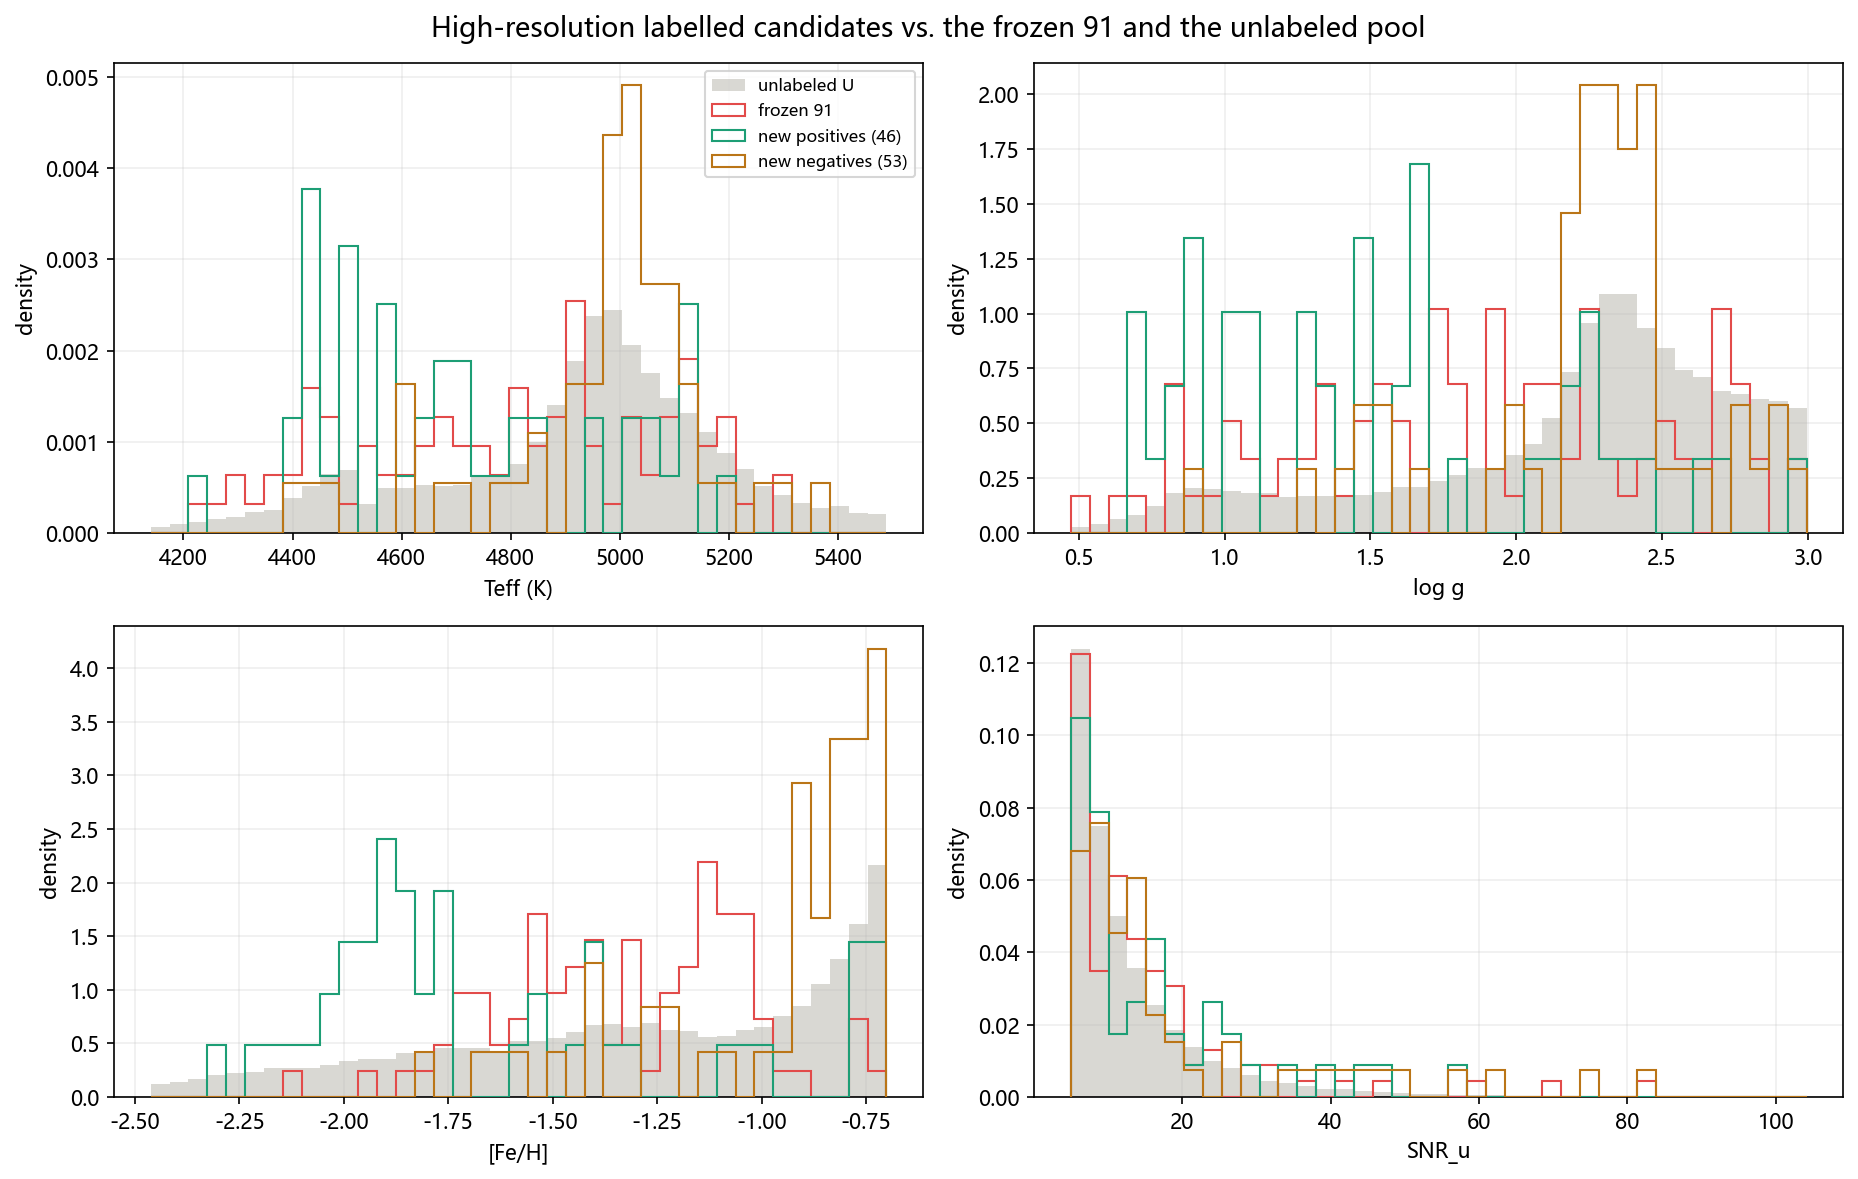

三个参数上是干净分离的：
  · Teff   : 4672 vs 5009 K
  · log g  : 1.46 vs 2.30  （新正样本更接近巨星）
  · [Fe/H] : -1.81 vs -0.84（差近 1 dex，分离最强）

含义：模型当前的假阳性，系统性地集中在
      『高温 / 高表面重力 / 富金属』这个星族区域。
      这与 Part 2 发现的 [Fe/H] +0.27 dex 偏移完全一致。


In [13]:
# 参数分布对比图（图由 run_newlabel_features.py 生成）

show_fig("fig5_newlabel_parameters.png")

print("三个参数上是干净分离的：")
print("  · Teff   : 4672 vs 5009 K")
print("  · log g  : 1.46 vs 2.30  （新正样本更接近巨星）")
print("  · [Fe/H] : -1.81 vs -0.84（差近 1 dex，分离最强）")
print()
print("含义：模型当前的假阳性，系统性地集中在")
print("      『高温 / 高表面重力 / 富金属』这个星族区域。")
print("      这与 Part 2 发现的 [Fe/H] +0.27 dex 偏移完全一致。")


In [14]:
# 顺带做的一件事：用独立标签检验"哪个排序键更能预测真假"
#
# 这直接检验了 Part 2 给出的建议——结果推翻了它。

v = nl["ranking_key_references"]
rows = []
for key, cn in [("auc_neg_feh", "-[Fe/H] 单独"),
                ("auc_neg_logg", "-log g 单独"),
                ("auc_xgb_pu_score", "xgb_pu_score 单独"),
                ("auc_rank_sum_score_and_knn50", "score + knn50 富集度"),
                ("auc_rank_sum_score_and_neg_feh", "score + (-[Fe/H])")]:
    rows.append({"排序键": cn, "AUC（区分新正 vs 新负）": v[key]})
val = nl["validation"]
for k in ("k20", "k50", "k200"):
    rows.insert(0, {"排序键": f"knn{k[1:]} 富集度",
                    "AUC（区分新正 vs 新负）": val[k]["auc_newpos_vs_newneg"]})
df = pd.DataFrame(rows).sort_values("AUC（区分新正 vs 新负）", ascending=False)
print(df.round(3).to_string(index=False))
print()
print("★ 重要修正：Part 2 曾建议『用 knn50 富集度替代 xgb_pu_score 做排序键』。")
print("  独立标签显示 knn50 的 AUC 是 0.872，低于 xgb_pu_score 的 0.911 —— 该建议不成立。")
print("  正确结论：富集度只适合做诊断与分层，不适合做排序。")
print()
print("★ 另一个线索：score + (-[Fe/H]) 达到 0.939，是目前最强组合。")
print("  但项目约定禁止把 [Fe/H] 作为 XGB 输入特征，这条约定值得重新评估。")


              排序键  AUC（区分新正 vs 新负）
score + (-[Fe/H])            0.939
  xgb_pu_score 单独            0.911
score + knn50 富集度            0.911
       knn200 富集度            0.884
        knn50 富集度            0.872
       -[Fe/H] 单独            0.855
        -log g 单独            0.813
        knn20 富集度            0.776



★ 重要修正：Part 2 曾建议『用 knn50 富集度替代 xgb_pu_score 做排序键』。
  独立标签显示 knn50 的 AUC 是 0.872，低于 xgb_pu_score 的 0.911 —— 该建议不成立。
  正确结论：富集度只适合做诊断与分层，不适合做排序。

★ 另一个线索：score + (-[Fe/H]) 达到 0.939，是目前最强组合。
  但项目约定禁止把 [Fe/H] 作为 XGB 输入特征，这条约定值得重新评估。


In [15]:
# 主实验结果：五种加入方式的 pooled out-of-fold AUC

res = load_json("addsample_results.json")
pc  = res["per_config"]
order = ["M0_baseline", "M1_add_pos", "M2_pos_plus_neg", "M4_new_pos_only", "M0_control"]
name_cn = {"M0_baseline": "M0 仅 91 颗（基线）",
           "M1_add_pos": "M1 加新正样本",
           "M2_pos_plus_neg": "M2 加新正 + 可靠负",
           "M4_new_pos_only": "M4 仅用新正样本",
           "M0_control": "随机标签对照"}

rows = []
for k in order:
    c = pc[k]
    rows.append({
        "配置": name_cn[k],
        "训练正样本数": int(c["n_train_pos_median"]),
        "AUC": c["auc_pooled_oof"],
        "95% CI 下界": c["auc_pooled_ci95"][0],
        "95% CI 上界": c["auc_pooled_ci95"][1],
        "recall@500": c["recall_at_500_mean"],
    })
print(pd.DataFrame(rows).round(4).to_string(index=False))
print()
print(f"判定规则：{res['verdict']['rule']}")
print(f"最终结论：{res['verdict']['conclusion']}")


           配置  训练正样本数    AUC  95% CI 下界  95% CI 上界  recall@500
M0 仅 91 颗（基线）      91 0.9176     0.8543     0.9690      0.8022
     M1 加新正样本     128 0.9299     0.8727     0.9759      0.9356
 M2 加新正 + 可靠负     128 0.9364     0.8803     0.9802      0.9356
    M4 仅用新正样本      37 0.9266     0.8649     0.9759      0.8533
       随机标签对照     128 0.8901     0.8171     0.9486      0.8044

判定规则：a gain counts only if the paired-bootstrap 95% CI of the AUC difference excludes zero AND the random control shows no gain
最终结论：no detectable improvement from adding positives


### 3.4 结果怎么读

主表给出的是点估计，但 99 个对象的样本量下，置信区间比点估计重要得多。
下面把关键对比的置信区间全部列出来。

In [16]:
# 关键对比：与基线比 vs 与随机对照比
#
# 这一节是整份 notebook 里信息密度最高的地方，值得慢慢读。

ph = load_json("addsample_posthoc.json")
ac = ph["auc_contrasts"]
name_cn2 = {
    "M1_add_pos_vs_M0_baseline": "M1 加新正　　vs 基线",
    "M2_pos_plus_neg_vs_M0_baseline": "M2 加新正+负　vs 基线",
    "M4_new_pos_only_vs_M0_baseline": "M4 仅新正　　vs 基线",
    "M0_control_vs_M0_baseline": "随机对照　　　vs 基线",
    "M1_add_pos_vs_M0_control": "M1 加新正　　vs 随机对照",
    "M2_pos_plus_neg_vs_M0_control": "M2 加新正+负　vs 随机对照",
    "M4_new_pos_only_vs_M0_control": "M4 仅新正　　vs 随机对照",
    "M2_pos_plus_neg_vs_M1_add_pos": "M2 vs M1（加不加负样本）",
}
rows = []
for key, cn in name_cn2.items():
    c = ac[key]
    verdict = ("显著增益" if c["significant_gain"] else
               ("显著退化" if c["significant_loss"] else "不显著"))
    rows.append({"对比": cn, "ΔAUC": c["mean_delta"],
                 "95% CI 下界": c["ci95"][0], "95% CI 上界": c["ci95"][1],
                 "判定": verdict})
print(pd.DataFrame(rows).round(4).to_string(index=False))


              对比    ΔAUC  95% CI 下界  95% CI 上界   判定
   M1 加新正　　vs 基线  0.0122    -0.0139     0.0397  不显著
  M2 加新正+负　vs 基线  0.0187    -0.0057     0.0453  不显著
   M4 仅新正　　vs 基线  0.0086    -0.0490     0.0708  不显著
    随机对照　　　vs 基线 -0.0276    -0.0567    -0.0037 显著退化
 M1 加新正　　vs 随机对照  0.0397     0.0033     0.0789 显著增益
M2 加新正+负　vs 随机对照  0.0462     0.0101     0.0871 显著增益
 M4 仅新正　　vs 随机对照  0.0361    -0.0272     0.1028  不显著
M2 vs M1（加不加负样本）  0.0065    -0.0021     0.0181  不显著


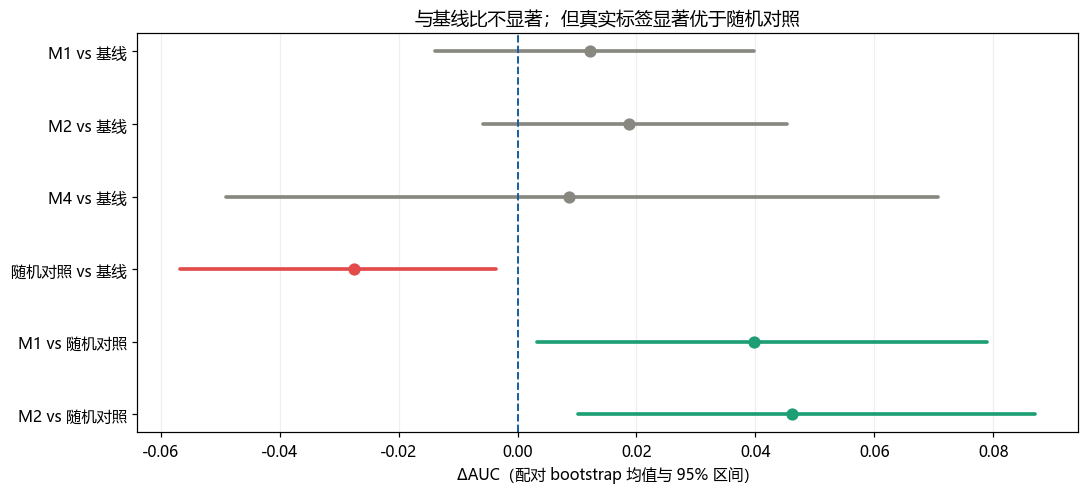

三句话读法：
  1) 加新样本 vs 基线：点估计为正，但置信区间跨越 0 → 不显著
  2) 随机对照 vs 基线：显著退化（-0.028，区间不含 0）→ 实验有分辨力
  3) 真实标签 vs 随机对照：显著增益（+0.040 / +0.046）→ 标签确实携带信息


In [17]:
# 把上面的置信区间画成森林图

fig, ax = plt.subplots(figsize=(10, 4.6))
keys = ["M1_add_pos_vs_M0_baseline", "M2_pos_plus_neg_vs_M0_baseline",
        "M4_new_pos_only_vs_M0_baseline", "M0_control_vs_M0_baseline",
        "M1_add_pos_vs_M0_control", "M2_pos_plus_neg_vs_M0_control"]
labels = ["M1 vs 基线", "M2 vs 基线", "M4 vs 基线", "随机对照 vs 基线",
          "M1 vs 随机对照", "M2 vs 随机对照"]
cols = ["#888780", "#888780", "#888780", "#E24B4A", "#1D9E75", "#1D9E75"]

ys = np.arange(len(keys))[::-1]
for y, k, lab, col in zip(ys, keys, labels, cols):
    c = ac[k]
    ax.plot(c["ci95"], [y, y], color=col, lw=2.4, solid_capstyle="round")
    ax.plot(c["mean_delta"], y, "o", color=col, ms=7)
ax.axvline(0, color="#185FA5", ls="--", lw=1.3)
ax.set_yticks(ys)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("ΔAUC（配对 bootstrap 均值与 95% 区间）")
ax.set_title("与基线比不显著；但真实标签显著优于随机对照", fontsize=12)
ax.grid(alpha=0.2, axis="x")
plt.tight_layout()
plt.show()

print("三句话读法：")
print("  1) 加新样本 vs 基线：点估计为正，但置信区间跨越 0 → 不显著")
print("  2) 随机对照 vs 基线：显著退化（-0.028，区间不含 0）→ 实验有分辨力")
print("  3) 真实标签 vs 随机对照：显著增益（+0.040 / +0.046）→ 标签确实携带信息")


In [18]:
# 唯一显著的、且对决策有实际意义的改善：候选表前 500 名的召回

rows = []
for k in order:
    c = pc[k]
    rows.append({"配置": name_cn[k],
                 "recall@500": c["recall_at_500_mean"],
                 "recall@1000": c["recall_at_1000_mean"],
                 "recall@2500": c["recall_at_2500_mean"]})
print(pd.DataFrame(rows).round(3).to_string(index=False))
print()

rt = ph["recall_paired_tests"]["recall_at_500"]
for k in ("M1_add_pos", "M2_pos_plus_neg", "M0_control"):
    e = rt[k]
    print(f"{name_cn[k]:<20} Δrecall@500 = {e['mean_delta']:+.4f}　"
          f"改善 {e['n_folds_improved']}/5 折　t = {e['t_statistic']:+.2f}")
print()
print("换成绝对数量：46 颗确认正样本中，能挤进前 500 名候选表的")
print("  基线约 37 颗  →  加样本后约 43 颗")
print()
print("注意：增益只在 K=500 处明显；K=1000 时降到 +0.02，K=2500 时基线已饱和(1.000)。")


           配置  recall@500  recall@1000  recall@2500
M0 仅 91 颗（基线）       0.802        0.958        1.000
     M1 加新正样本       0.936        0.978        1.000
 M2 加新正 + 可靠负       0.936        0.978        1.000
    M4 仅用新正样本       0.853        0.936        0.978
       随机标签对照       0.804        0.936        1.000

M1 加新正样本             Δrecall@500 = +0.1333　改善 4/5 折　t = +3.21
M2 加新正 + 可靠负         Δrecall@500 = +0.1333　改善 4/5 折　t = +3.21
随机标签对照               Δrecall@500 = +0.0022　改善 1/5 折　t = +0.04

换成绝对数量：46 颗确认正样本中，能挤进前 500 名候选表的
  基线约 37 颗  →  加样本后约 43 颗

注意：增益只在 K=500 处明显；K=1000 时降到 +0.02，K=2500 时基线已饱和(1.000)。


In [19]:
# 机制：三种加入方式，差别不在"加了多少"，在"有没有约束住阴性一侧"

mv = ph["score_movement"]
rows = []
for k in ("M1_add_pos", "M2_pos_plus_neg", "M4_new_pos_only", "M0_control"):
    p = mv[k]["new_positives"]
    n = mv[k]["new_negatives"]
    rows.append({"配置": name_cn[k],
                 "46 颗真阳性 Δscore": p["mean_delta"],
                 "其中分数上升比例": f"{p['share_increased'] * 100:.0f}%",
                 "53 颗真阴性 Δscore": n["mean_delta"],
                 "其中分数上升比例": f"{n['share_increased'] * 100:.0f}%"})
print(pd.DataFrame(rows).round(4).to_string(index=False))
print()
print("● M1：真阳性 +0.150，但真阴性也 +0.028 → 『一起涨』，净分离被稀释")
print("● M2：真阳性 +0.109，真阴性只 +0.003 → 只抬该抬的（把确认非增丰的样本")
print("      强制作为负样本，等于直接告诉模型『这些高分对象不是正类』）")
print("● M4：两者都涨得较多")
print("● 随机对照：真阳性 -0.084（被压低）、真阴性 +0.029（被抬高）→ 两个方向同时恶化")
print()
print("→ 这解释了随机对照为什么显著变差，也说明本次实验的判据是有分辨力的。")


          配置  46 颗真阳性 Δscore 其中分数上升比例  53 颗真阴性 Δscore
    M1 加新正样本          0.1504      60%          0.0277
M2 加新正 + 可靠负          0.1091      28%          0.0030
   M4 仅用新正样本          0.1331      68%          0.0217
      随机标签对照         -0.0835      81%          0.0289

● M1：真阳性 +0.150，但真阴性也 +0.028 → 『一起涨』，净分离被稀释
● M2：真阳性 +0.109，真阴性只 +0.003 → 只抬该抬的（把确认非增丰的样本
      强制作为负样本，等于直接告诉模型『这些高分对象不是正类』）
● M4：两者都涨得较多
● 随机对照：真阳性 -0.084（被压低）、真阴性 +0.029（被抬高）→ 两个方向同时恶化

→ 这解释了随机对照为什么显著变差，也说明本次实验的判据是有分辨力的。


### 3.4 Part 3 小结

**问题**：加样本有用吗？

| 层次 | 结论 | 证据 |
|---|---|---|
| 标签有没有信息 | **有** | 真标签显著优于随机标签（+0.040 / +0.046） |
| 对基线有没有可测提升 | **没有**（AUC 层面） | +0.013 / +0.019，CI 跨 0 |
| 实验有没有分辨力 | **有** | 随机对照显著退化 −0.028 |
| 对候选表有没有实际改善 | **有** | recall@500：0.802 → **0.936**，4/5 折改善 |
| 最好的加入方式 | M2（正样本 + 可靠负样本） | 点估计最高，且不浪费已获得的负标签 |
| M2 显著优于 M1 吗 | **不显著**（+0.0065） | 选 M2 的理由是"用上了负样本信息"，不是"指标更高" |

**三条可操作结论**：

1. **53 颗确认非增丰的样本是资产，不是废料。** 把它们从 U 中移除并在每轮 bag 中强制作为负样本，
   是目前最好的用法。建议后续每批观测都这样积累。
2. **应调整对"加样本"的预期。** 46 颗正样本处在"方向正确但测不出显著性"的区间。
   按本次效应量估算，要稳定检出约需 **3–4 倍**标签量 → 应**持续小批量积累**，而不是等一批大的。
3. **单批扩充的主要产出是"候选表更干净"，不是"指标更好看"。**
   recall@500 的 +0.133 是真实收益，但它不会体现在 AUC 上。


---
# Part 4 — 那"准确度"到底是多少？

## 4.1 一个一直悬着的问题

项目 README 里的标杆数字是 **`xgb_threshold`：ROC-AUC 0.9883、PR-AUC 0.6030**。

但这个数字是在 **6,187 颗留出测试集**上算的——而测试集里的正样本，仍然来自**同一批 91 颗文献样本**，
而模型就是用它们训练的（实际训练只用了其中 63 颗）。

**所以这个数字回答的是**："模型能不能把自己学过的这类星排到前面？"
**而不是**："模型能不能找到 CN 星？"

Part 3 给了我们 99 个独立标签。现在可以第一次给这个模型一个**不参与训练**的评分。

## 4.2 做法

1. **忠实复现** `XGB/run_comparison.py` 的 baseline 分支
   （同样的划分：test_size=0.15 / val 0.18、seed=42；同样 500 bags、700 维、等概率负采样），
   并**核验**能否逐位复现官方数字——不能复现就没有比较的意义；
2. 拿全量 41,243 个对象的分数，用 99 个独立标签做外部评估；
3. 用同一批标签给冻结的 `crossfit` 分数也评一遍，两个模型放在同一把尺子上比。


In [20]:
# 复现核验：先看能不能把官方数字做出来

ta = load_json("threshold_audit.json")
pr = ta["protocol"]
print("【复现核验】")
print(f"  官方 ROC-AUC : {pr['reference_roc']:.6f}")
print(f"  重跑 ROC-AUC : {pr['reproduced_roc']:.6f}")
print(f"  官方 PR-AUC  : {pr['reference_pr']:.6f}")
print(f"  重跑 PR-AUC  : {pr['reproduced_pr']:.6f}")
print(f"  → {'逐位一致 ✓' if pr['reproduced_baseline'] else '不一致 ✗'}")
print()
print(f"  模型自身阈值 : {pr['threshold']:.4f}")
print(f"  训练正样本数 : 63（91 颗里落在训练划分的那部分）")
print(f"  测试集大小   : {pr['evaluation_split_size']:,}")
print()
print("复现成功，说明下面的独立评估与官方结果出自同一个模型，可以放心对比。")


【复现核验】
  官方 ROC-AUC : 0.988302
  重跑 ROC-AUC : 0.988302
  官方 PR-AUC  : 0.602996
  重跑 PR-AUC  : 0.602996
  → 逐位一致 ✓

  模型自身阈值 : 0.5776
  训练正样本数 : 63（91 颗里落在训练划分的那部分）
  测试集大小   : 6,187

复现成功，说明下面的独立评估与官方结果出自同一个模型，可以放心对比。


In [21]:
# 独立标签下的真实表现

ia = ta["independent_audit"]
rows = []
for key, cn in [("xgb_threshold", "xgb_threshold（官方标杆）"),
                ("crossfit90", "crossfit recall90")]:
    a = ia[key]
    rows.append({
        "模型": cn,
        "AUC（99 独立标签）": a["auc_on_99"],
        "标准误": a["auc_std_error"],
        "PR-AUC": a["pr_auc_on_99"],
        "确认增丰中位分数": a["median_score_positive"],
        "确认非增丰中位分数": a["median_score_negative"],
    })
print(pd.DataFrame(rows).round(3).to_string(index=False))
print()
for key, cn in [("xgb_threshold", "xgb_threshold"), ("crossfit90", "crossfit90")]:
    a = ia[key]
    print(f"{cn:<16} 在自身阈值之上：确认增丰 {a['share_positive_above_threshold'] * 100:.0f}%"
          f"　确认非增丰 {a['share_negative_above_threshold'] * 100:.0f}%")
print()
print("★ 关键读法：两个模型的中位分数差（正 vs 负）")
print("   xgb_threshold : 0.800 vs 0.653 → 只差 0.147，且 99 颗全部在阈值之上")
print("   crossfit90    : 0.515 vs 0.054 → 分离清晰")


                 模型  AUC（99 独立标签）   标准误  PR-AUC  确认增丰中位分数  确认非增丰中位分数
xgb_threshold（官方标杆）         0.782 0.047   0.775     0.800      0.653
  crossfit recall90         0.911 0.031   0.876     0.515      0.054

xgb_threshold    在自身阈值之上：确认增丰 100%　确认非增丰 100%
crossfit90       在自身阈值之上：确认增丰 43%　确认非增丰 6%

★ 关键读法：两个模型的中位分数差（正 vs 负）
   xgb_threshold : 0.800 vs 0.653 → 只差 0.147，且 99 颗全部在阈值之上
   crossfit90    : 0.515 vs 0.054 → 分离清晰


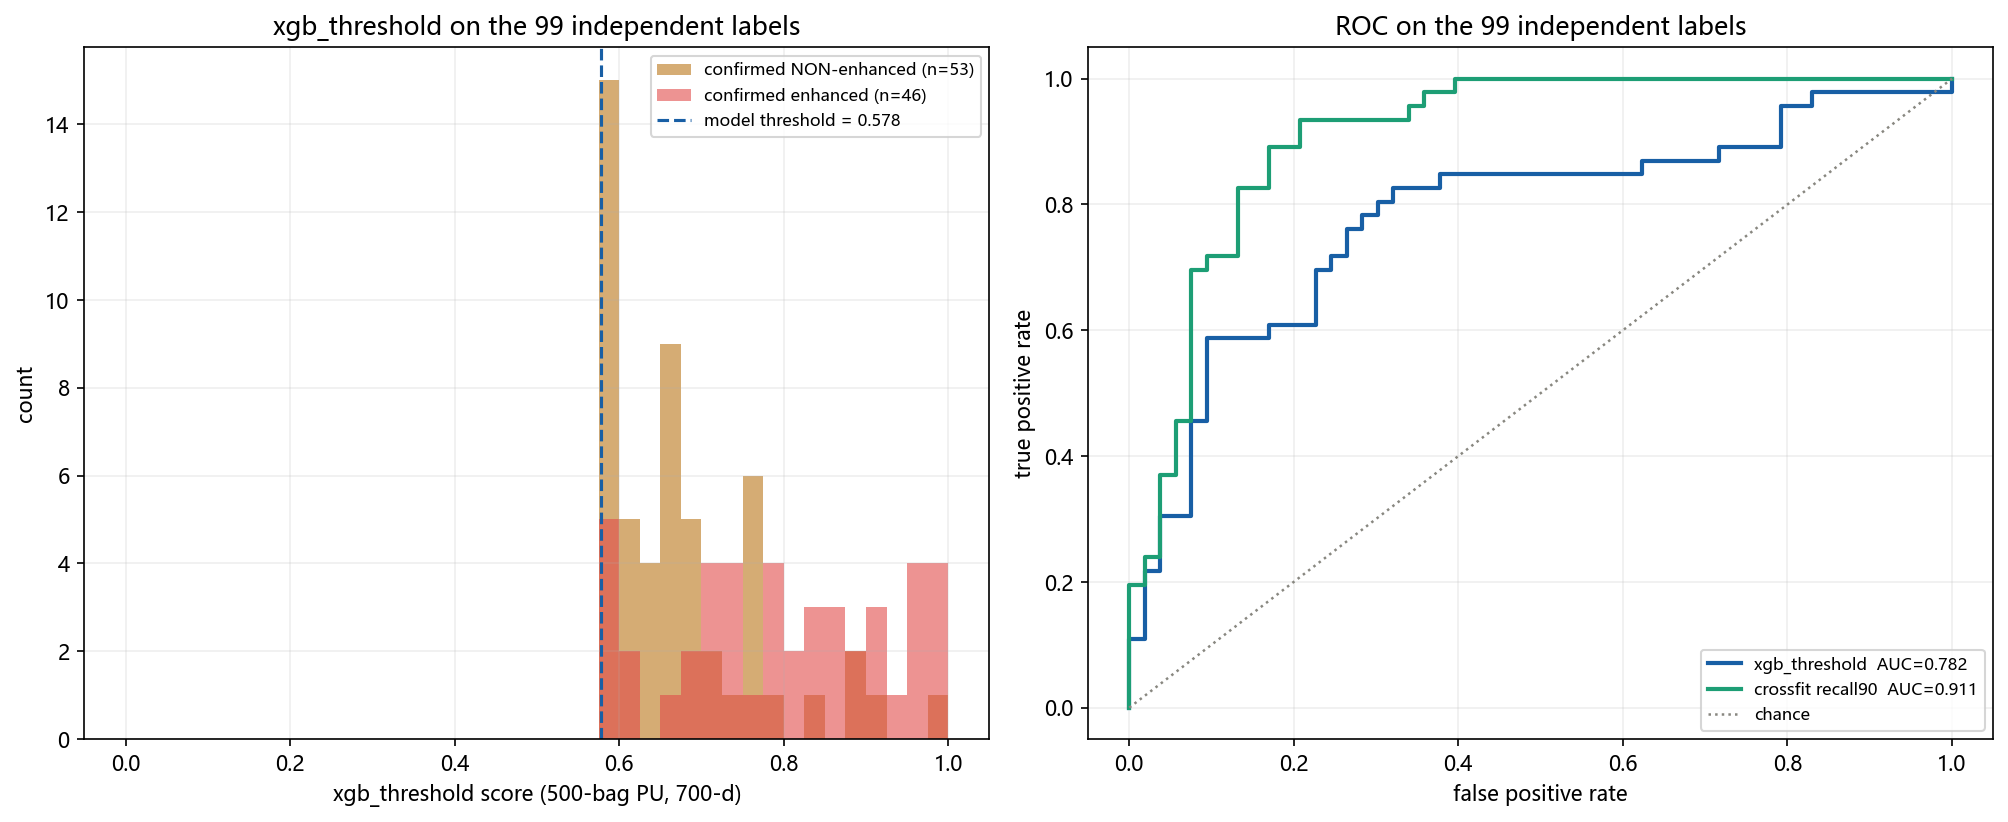

左图：99 颗的分数分布。确认增丰（红）与确认非增丰（黄）在 0.6–0.8 之间几乎完全重叠；
      所有对象都在模型阈值 0.578 之上 —— 在这个群体里，阈值不提供任何筛选作用。
右图：同一批标签上的 ROC。crossfit（绿）明显高于 xgb_threshold（蓝）。


In [22]:
# 可视化（图由 run_threshold_audit.py 生成）

show_fig("fig8_threshold_audit.png")

print("左图：99 颗的分数分布。确认增丰（红）与确认非增丰（黄）在 0.6–0.8 之间几乎完全重叠；")
print("      所有对象都在模型阈值 0.578 之上 —— 在这个群体里，阈值不提供任何筛选作用。")
print("右图：同一批标签上的 ROC。crossfit（绿）明显高于 xgb_threshold（蓝）。")


In [23]:
# 两个数字为什么差这么多？—— 不是"虚高"，是回答了两个不同的问题

rows = [
    {"": "正样本", "官方口径（6,187 颗留出集）": "28 颗（91 的 15%）",
     "独立标签口径（99 颗）": "46 颗确认增丰"},
    {"": "负样本", "官方口径（6,187 颗留出集）": "≈6,159 颗【随机未标注星】",
     "独立标签口径（99 颗）": "53 颗【确认非增丰的候选，硬负样本】"},
    {"": "负样本难度", "官方口径（6,187 颗留出集）": "大多是普通星，容易分",
     "独立标签口径（99 颗）": "全部来自高分区，很难分"},
    {"": "它回答的问题", "官方口径（6,187 颗留出集）": "能不能排到随机星之前？",
     "独立标签口径（99 颗）": "能不能在候选池内部挑出真星？"},
    {"": "答案", "官方口径（6,187 颗留出集）": "几乎完美（0.988）",
     "独立标签口径（99 颗）": "明显吃力（0.782）"},
]
print(pd.DataFrame(rows).to_string(index=False))
print()
print("项目实际要做的是第二件事——候选表就是要在高分区里往外挑，")
print("竞争发生在候选池内部，而不是候选 vs 随机星。")
print("所以决定候选表质量的是 0.782，不是 0.9883。")


       官方口径（6,187 颗留出集）        独立标签口径（99 颗）
   正样本   28 颗（91 的 15%）            46 颗确认增丰
   负样本 ≈6,159 颗【随机未标注星】 53 颗【确认非增丰的候选，硬负样本】
 负样本难度       大多是普通星，容易分         全部来自高分区，很难分
它回答的问题      能不能排到随机星之前？      能不能在候选池内部挑出真星？
    答案      几乎完美（0.988）         明显吃力（0.782）



项目实际要做的是第二件事——候选表就是要在高分区里往外挑，
竞争发生在候选池内部，而不是候选 vs 随机星。
所以决定候选表质量的是 0.782，不是 0.9883。


In [24]:
# 这和项目 8-28 的一份分析完全吻合
#
# 那份分析用『重要性采样』从另一条路径得到了同一结论。

fs = ta["feh_shortcut_documented"]
print("XGB/XGB_PU_实验结果分析.md（2026-08-28）的发现：")
print(f"  基线（等概率负采样）            PR-AUC = {fs['headline_pr']:.4f}")
print(f"  3D 分箱匹配（[Fe/H] 对齐到正样本）PR-AUC = {fs['pr_after_feh_matched_negative_sampling']:.4f}")
print(f"  feh-only KDE 加权                PR-AUC = {fs['pr_feh_only_kde']:.4f}")
print()
print("本轮独立标签从完全不同的路径证实了它：")
nlp = load_json("newlabel_features.json")["parameters"]
print(f"  新正样本 [Fe/H] 中位 = {nlp['new_positives']['feh_median']:.2f}")
print(f"  新负样本 [Fe/H] 中位 = {nlp['new_negatives']['feh_median']:.2f}")
print(f"  两者相差 {nlp['new_positives']['feh_median'] - nlp['new_negatives']['feh_median']:.2f} dex")
print(f"  而 [Fe/H] 单独一个变量的 AUC = "
      f"{load_json('newlabel_features.json')['ranking_key_references']['auc_neg_feh']:.3f}")
print()
print("→ 两条独立证据链（采样消融 + 独立标签）指向同一结论。")
print("  建议把『[Fe/H] 是主导混淆变量』从『一个实验观察』升级为项目已确证结论。")
print("→ 解耦方向在特征层（金属丰度校正后的 CN 残差），不在采样层。")


XGB/XGB_PU_实验结果分析.md（2026-08-28）的发现：
  基线（等概率负采样）            PR-AUC = 0.6030
  3D 分箱匹配（[Fe/H] 对齐到正样本）PR-AUC = 0.4495
  feh-only KDE 加权                PR-AUC = 0.4435

本轮独立标签从完全不同的路径证实了它：


  新正样本 [Fe/H] 中位 = -1.81
  新负样本 [Fe/H] 中位 = -0.84
  两者相差 -0.97 dex
  而 [Fe/H] 单独一个变量的 AUC = 0.855

→ 两条独立证据链（采样消融 + 独立标签）指向同一结论。
  建议把『[Fe/H] 是主导混淆变量』从『一个实验观察』升级为项目已确证结论。
→ 解耦方向在特征层（金属丰度校正后的 CN 残差），不在采样层。


### 4.3 Part 4 小结

| 口径 | 评估集 | ROC-AUC | PR-AUC |
|---|---|---:|---:|
| 官方（自证） | 6,187 颗留出集 | 0.9883 | 0.6030 |
| **独立标签** | 99 个高分辨率标签 | **0.782 ± 0.047** | 0.775 |
| crossfit（同一批标签） | 99 个高分辨率标签 | **0.911 ± 0.031** | 0.876 |

**三条结论**：

1. **0.9883 不是"错"的，但它回答的不是项目关心的问题。** 把它当作模型能力的对外表述会高估。
   对外应使用独立口径的数字。
2. **crossfit 在独立尺子上优于 xgb_threshold（0.911 vs 0.782，差约 2.4 个标准误），
   而且这个比较对 xgb_threshold 有利**（99 颗本来就是用模型高分筛出来的，存在偏向它的选择偏差）。
   README 里"XGBoost PU Bagging 是当前最稳定的标杆"需要修正。
3. **该模型在自己的阈值处，对这 99 颗毫无区分力**（正负样本 100% 都在阈值之上）。
   按这个阈值切，精度就是 46/99 ≈ 46.5%。


---
# 5. 总结：这四组实验的整体意义

## 5.1 一张总表

| Part | 问题 | 最关键的发现 | 数字 |
|---|---|---|---|
| 1 | 模型哪里不行？ | 问题高度集中，且现有提名方式恰好绕开失败区 | 85/91 落在 U 最高 5%；困难正例的邻域富集 **0.000** |
| 2 | 候选池可靠吗？ | 模型分数本身是主要信号源；两法不等价；候选是混合体 | 两法都否 **12.9×**、两法一致 **26.0×**、正例 **65×** |
| 3 | 加样本有用吗？ | 标签有信息但效应小；唯一实际收益在候选表召回 | AUC +0.019（不显著）；recall@500 **0.802→0.936** |
| 4 | 准确度是多少？ | 官方数字是自证口径；独立口径低 0.21 | **0.9883 → 0.782**；crossfit 0.911 |

## 5.2 五条最重要的意义

**① 项目第一次拥有了"外部标尺"，这比模型本身更重要。**
在此之前所有指标的分母正样本都来自同一批 91 颗。99 个独立标签让我们第一次能问
"这个模型到底有多准"，并且答案与原来的认知相差 0.21。

**② "[Fe/H] 是主导混淆变量"从假说变成了确证结论。**
8-28 通过重要性采样发现，本轮通过独立标签证实。两条独立证据链同一结论。
这直接影响模型该怎么改：**解耦放在特征层**（金属丰度校正后的 CN 残差），不在采样层。

**③ 加样本的收益上限由"特征里有多少信息"决定，不由样本数量决定。**
Part 1 显示特征空间里正类成簇（可学），但非常松散；
Part 2 显示候选的富集主要来自模型分数本身；
Part 3 显示 46 颗新标签的边际效应低于当前可分辨能力。
**所以正确的问题不是"再标多少颗"，而是"标哪里的、以及模型能不能用上"。**

**④ 已经拿到三样立刻可用的东西。**
- **53 颗硬负样本** → M2 训练配方（正样本 + 可靠负样本），目前最好的加入方式；
- **一份分层候选表**（`candidate_reliability.csv`）→ 高富集度的候选可直接作为下一批观测对象；
- **一套独立评估协议**（交叉拟合 + 随机标签对照 + 配对 bootstrap）→ 后续任何改动都能用同一把尺子衡量。

**⑤ 对"投入观测资源"这件事的预期要校准。**
单批 46 颗正样本处于"方向正确但测不出显著性"的区间，约需 3–4 倍才能稳定检出。
**结论：持续小批量积累 + 每批都做受控对照，优于等一批大的。**

## 5.3 下一步（按优先级）

| 优先级 | 动作 | 依据 |
|---|---|---|
| **P0** | 采用 M2 配方训练后续模型：正样本加入，确认非增丰的样本作为可靠负样本 | Part 3 |
| **P0** | 对外汇报改用独立口径数字，README 修订标杆表述 | Part 4 |
| **P1** | 复核"禁止 Teff/logg/[Fe/H] 作为 XGB 输入"的约定 | Part 3（score + (-[Fe/H]) = 0.939） |
| **P1** | 修订 `feature/` 方案：面积法降级、增加 [Fe/H] 残差化 | Part 2 |
| **P2** | 按 `candidate_reliability.csv` 的高富集层提名下一批观测对象 | Part 2、Part 3 |
| **P3** | 特征层解耦（金属丰度校正的 CN 残差）试点 | Part 2、Part 4 |

## 5.4 一句话

> **这四组实验最大的产出不是"一个更好的模型"，而是"一套能判断方案是否有效的方法"。**
> 加样本这条路没有被否定，但它被量化了：**方向正确、效应有限、
> 而且必须先解决特征层面的 [Fe/H] 混淆，否则只是在同一块天花板上反复试探。**


---
# 6. 复现命令

本 notebook 只读取结果文件，不重跑实验。要重跑，使用 `diagnosis/` 下的四个脚本：

```powershell
# 统一使用项目解释器
D:/Anaconda/envs/myenv/python.exe <script>
```

| 脚本 | 产出 | 约需时间 |
|---|---|---|
| `diagnosis/run_d1_d2.py` | D1 分数谱 + D2 邻域结构（直接读冻结分数，不重跑模型） | ~5 分钟 |
| `diagnosis/run_candidate_analysis.py` | 候选富集度阶梯与可靠性表 | ~1 分钟 |
| `diagnosis/run_newlabel_features.py` | 99 个新标签的特征分析与排序键检验 | ~1 分钟 |
| `diagnosis/run_addsample_experiment.py` | 5 折 × 5 配置的加样本对照实验（**最慢**） | ~26 分钟 |
| `diagnosis/run_addsample_posthoc.py` | 补充对比（读上一行的产出，不重训） | ~1 分钟 |
| `diagnosis/run_threshold_audit.py` | 复现 xgb_threshold + 独立标签审计 | ~4 分钟 |

**调试技巧**：`run_addsample_experiment.py` 支持 `--bags 3 --fold-limit 2`，十几秒就能跑通流程。

**重新生成本 notebook**：

```powershell
D:/Anaconda/envs/myenv/python.exe diagnosis/build_diagnosis_notebook.py
```

**关键文件速查**：

| 文件 | 内容 |
|---|---|
| `diagnosis/cands_label.csv` | 99 个高分辨率独立标签（46 正 / 53 负） |
| `diagnosis/results/candidate_reliability.csv` | 171 颗 tier-1 候选的分层与富集度 |
| `diagnosis/results/known_cn_diagnosis.csv` | 91 颗逐星诊断表 |
| `diagnosis/results/addsample_oof_scores.csv` | 99 个标签对象在 5 种配置下的样本外分数 |
| `diagnosis/results/CONCLUSION*.md` | 四份详细报告（本 notebook 是其通俗版） |
